# Annotating comments with a local LLM

Proof of concept for a possible prAxIs notebook on using language models to label text data. It follows the workflow in Fang et al., *A Methodological Guide on Using Large Language Models for Text Annotation in the Social Sciences and Humanities*: annotate zero-shot, score against human labels, then fine-tune and score again.

We want to show that the improvement is measurable and that the whole thing runs on one consumer graphics card, so students could actually do it themselves. Everything below was produced locally on my PC (2070super, 16gb ram, i7 13th). We use a local model to avoid the OpenAI/Anthtopic privacy forms

## The data

Two corpora from SFU's Discourse Lab, both built from *Globe and Mail* comment threads. This is data created locally from SFU and gives us tons of options for specific topics (war, economy, elections, politices etc if we want to dig deeper).

The gold set is the SFU Opinion and Comments Corpus: 1,043 comments that crowd workers labelled constructive or not. Constructive means the comment adds something to the conversation, like a specific point, evidence, a personal experience, or a proposed solution. About a fifth of the set was re-annotated by experts, and crowd and expert agree only 78.5% of the time. Worth keeping that number in mind when we judge the model. These 1,043 comments are held back and never trained on.

The training set is the Constructive Comments Corpus (C3): 12,000 comments with the same kind of annotation. We checked whether any gold comments leak into it, since that would inflate our results. Exactly one row overlapped, and we dropped it.

The scored sample below is 100 comments from the gold set (we can expand this to larger number like 500 and then computational time increase, will be most likely worth it), balanced 50/50 so accuracy is easy to read. Both corpora are CC BY-NC, and the gold set adds ShareAlike, so they work for a non-commercial teaching resource as long as we attribute them.

In [1]:
import numpy as np
import pandas as pd

results = pd.read_csv("data/model_vs_human_labels.csv")
results[["comment_text", "gold", "zero_shot", "fine_tuned"]].head()

,comment_text,gold,zero_shot,fine_tuned
0,Stop it with the subtle (not really) insinuati...,yes,yes,yes
1,Certainly. The 15% tax on 'non-residents' is t...,yes,yes,yes
2,please.... man what a rag this thing has turne...,no,no,no
3,And we wont be fooled by Justin and Thomas.,no,no,no
4,There were KKK members who voted for Trump. Th...,yes,no,yes


In [2]:
results[["gold", "zero_shot", "fine_tuned"]].apply(pd.Series.value_counts)

,gold,zero_shot,fine_tuned
no,50,80,57
yes,50,20,43


## The model

Qwen3-1.7B, an open-weights instruction model, quantised to 4 bits. Quantisation stores the weights at lower precision, which shrinks the model to about 1.3 GB and lets it run on an 8 GB RTX 2070 Super with room to spare. It peaked at 4.9 GB during training. A student with a gaming laptop can run this.

It is a small model by current standards, and thats good for this case. A modern flagship model would annotate this well straight out of the box and there would be nothing left to show. A 1.7B model does badly enough zero-shot that the improvement is visible.

The model weights and the fine-tuned adapter are cached outside this folder, so the repo only carries the data and the notebook.


## Asking it to annotate

Zero-shot means we describe the task and ask, with no examples and no training. Each comment goes into this prompt, and the model replies in a fixed format we can parse:

```
You are annotating reader comments from a Canadian news website.

A comment is CONSTRUCTIVE if it tries to add something to the conversation: it makes a
specific point, gives evidence or a personal experience, offers a solution, or engages
with the article's argument.

A comment is NOT CONSTRUCTIVE if it is only an insult, a one-line dismissal, sarcasm
with no substance, off-topic ranting, or an unsupported assertion.

Comment:
"""{comment}"""

Reply in exactly this format and nothing else:
LABEL: yes
REASON: <one short sentence>
```

All 100 comments parsed cleanly, so the format holds up.

## Fine-tuning it

Fine-tuning normally updates every weight in the model, which needs far more memory than we have. QLoRA (https://arxiv.org/abs/2305.14314) gets around that. The model stays frozen at 4 bits and we train a small set of new weights bolted onto it. Here that comes to 17 million trainable parameters, 1.66% of the model, and the saved result is a 77 MB file instead of a fresh copy of the whole thing.

We trained on 2,000 comments from C3 for 200 steps, which takes about 25 minutes. Each training example pairs the prompt above with the human label, and we score the model only on the label it produces, so it spends no effort learning to reproduce the prompt back to us.

Two hardware details mattered. This GPU is old enough that it has no native support for the bfloat16 number format that everything now defaults to, so we forced training into float16. And comments are short, so a 512-token limit covers 99% of them.

## Does it work?

Accuracy is the share labelled correctly. Cohen's kappa and Krippendorff's alpha both discount the agreement you would get by chance, which matters here because guessing gets you 50% on a balanced two-class problem. Those two are the numbers to trust.

In [3]:
!pip install --quiet krippendorff

import krippendorff
from sklearn.metrics import accuracy_score, cohen_kappa_score, f1_score


def agreement(human, model):
    h = (human == "yes").astype(int)
    m = (model == "yes").astype(int)
    return {
        "accuracy": accuracy_score(h, m),
        "f1": f1_score(h, m),
        "cohen_kappa": cohen_kappa_score(h, m),
        "krippendorff_alpha": krippendorff.alpha([h, m], level_of_measurement="nominal"),
    }


scores = pd.DataFrame({
    "zero-shot": agreement(results.gold, results.zero_shot),
    "fine-tuned": agreement(results.gold, results.fine_tuned),
}).round(3)
scores

,zero-shot,fine-tuned
accuracy,0.680,0.830
f1,0.543,0.817
cohen_kappa,0.360,0.660
krippendorff_alpha,0.300,0.660


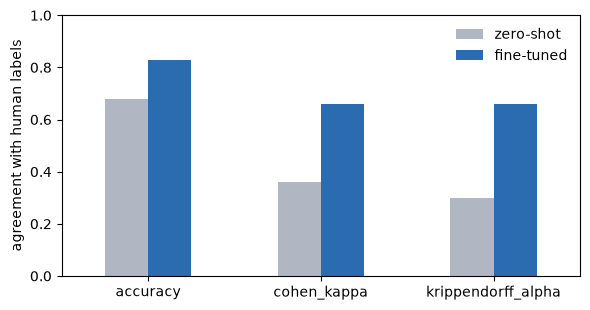

In [4]:
import matplotlib.pyplot as plt

ax = scores.drop("f1").plot.bar(rot=0, figsize=(6, 3.2), color=["#b0b7c3", "#2b6cb0"])
ax.set_ylim(0, 1)
ax.set_ylabel("agreement with human labels")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

Kappa nearly doubles, 0.36 to 0.66, for 25 minutes of training.

The more interesting part is how the zero-shot model got it wrong. Half the sample is constructive, and it was very reluctant to say so:

In [5]:
pd.DataFrame({
    "share called constructive": [
        (results.zero_shot == "yes").mean(),
        (results.fine_tuned == "yes").mean(),
        (results.gold == "yes").mean(),
    ]
}, index=["zero-shot", "fine-tuned", "human"])

,share called constructive
zero-shot,0.20
fine-tuned,0.43
human,0.50


That is a good thing for students to find. The failure has a shape, so you can reason about how to fix it and then check whether your fix worked.

Fine-tuning costs us something too. The zero-shot model explains its answers. The fine-tuned one was trained on bare labels, so it stopped:

In [6]:
row = results.iloc[0]

print(row.comment_text[:300], "\n")
print("zero-shot  ->", row.zero_shot_output)
print("fine-tuned ->", row.fine_tuned_output)

Stop it with the subtle (not really) insinuation. 99% of people who oppose the abuse of our housing market by 'foreign' money would oppose it just as much if it was 'foreign' white Russians with blue eye and blond hair. The problem is not who the buyers are, it's what they are doing to our quality o 

zero-shot  -> LABEL: yes
REASON: The comment provides a specific point by identifying the issue as the actions of the buyers rather than their nationality.
fine-tuned -> LABEL: yes


Worth spelling that trade out in any notebook we build from this. The model got more accurate and harder to inspect at the same time.

## Next steps

The pipeline works end to end, so the open question is what it takes to turn this into something we would actually put in front of students.

**Score the full gold set.** We only scored 100 comments, so the margin of error on 83% accuracy is about 7 points either way. All 1,043 can be used.

**Train on all of C3.** We used 2,000 of the 12,000 available comments for 200 steps. One pass over the whole set takes about an 1hr 15mins on this card. More variety will probably buy us more than more passes over the same 2,000.

**Add more labels.** Right now we ask one binary question, which is the easiest possible version of the task. C3 also records why a comment is constructive (specific points, evidence, dialogue) and why it is not (provocative, unsupported assertion), plus a four-level toxicity rating with its own characteristics like personal attack, abusive, and teasing. That gives us a multi-label problem and a graded one, both closer to what real annotation looks like, and it lets students watch the metrics behave as the label space gets harder. Toxicity needs cleaning first: in the gold set 643 of the 1,043 rows hold several annotator answers jammed into one field, so we need a documented rule for aggregating them before it can be a label at all.

**Do the prompt improvement step.** Fang et al. put prompt iteration between zero-shot and fine-tuning and we didn't do this part. It is the part students can do on a laptop with no GPU, so it is probably the most valuable section of the whole thing. It needs a proper three-way split: a small set to read while writing prompts, a second to choose between candidates, and the gold set sealed until the very end.

**Get the reasons back.** Training on bare labels cost us the explanations. Training on labels that carry a one-line justification should keep them, and it would let students inspect why the model decided what it did instead of taking the label on faith.

**Sort out data access.** C3 only comes from Kaggle and needs an account. So I gotta look into how to carry over this data for students.

**Ship the cached annotations.** If we commit the saved model outputs alongside the notebook, it runs start to finish with no GPU and no downloads. For notebooks in browser this what I will do.